# Installations

A reminder to select the runtime type as 'T4-GPU'

`Runtime` -> `Change runtime type` -> `T4 GPU`

In [ ]:
# Install necessary packages and dependencies
!pip install ase
!pip install nequip
!pip install opt_einsum
!pip install torch_ema
!pip install prettytable

# Geometric Tensors and Equivariance

In the lecture, you might have heard the terms 'Tensor Product', 'Spherical Harmonics', 'Clebsch-Gordan Coefficients' etc. Let's quickly become a bit more familiar with them before entering into MLIPs. Main aim of the following illustration:

*   Recap of the lecture
*   What are the design choices/hyperparameters in my control?



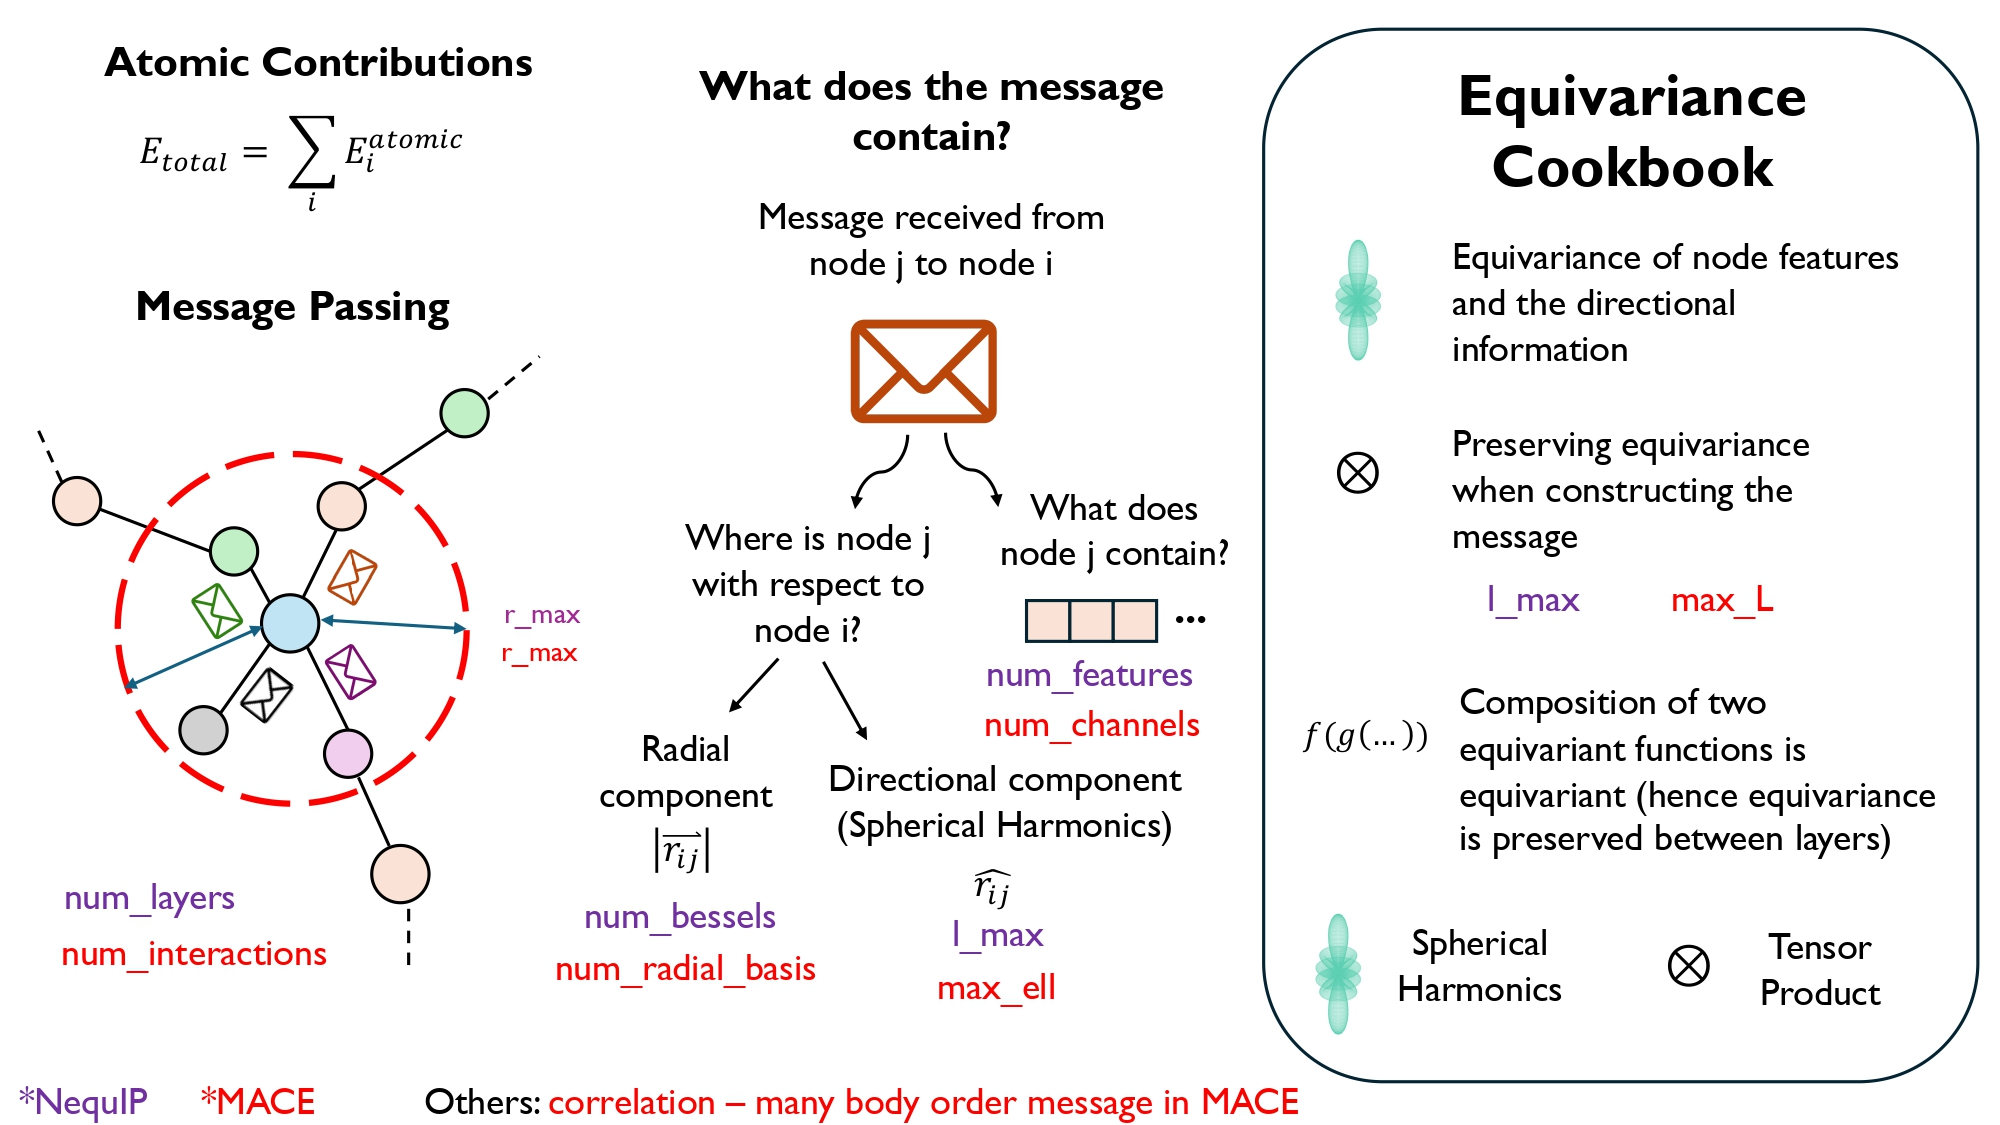

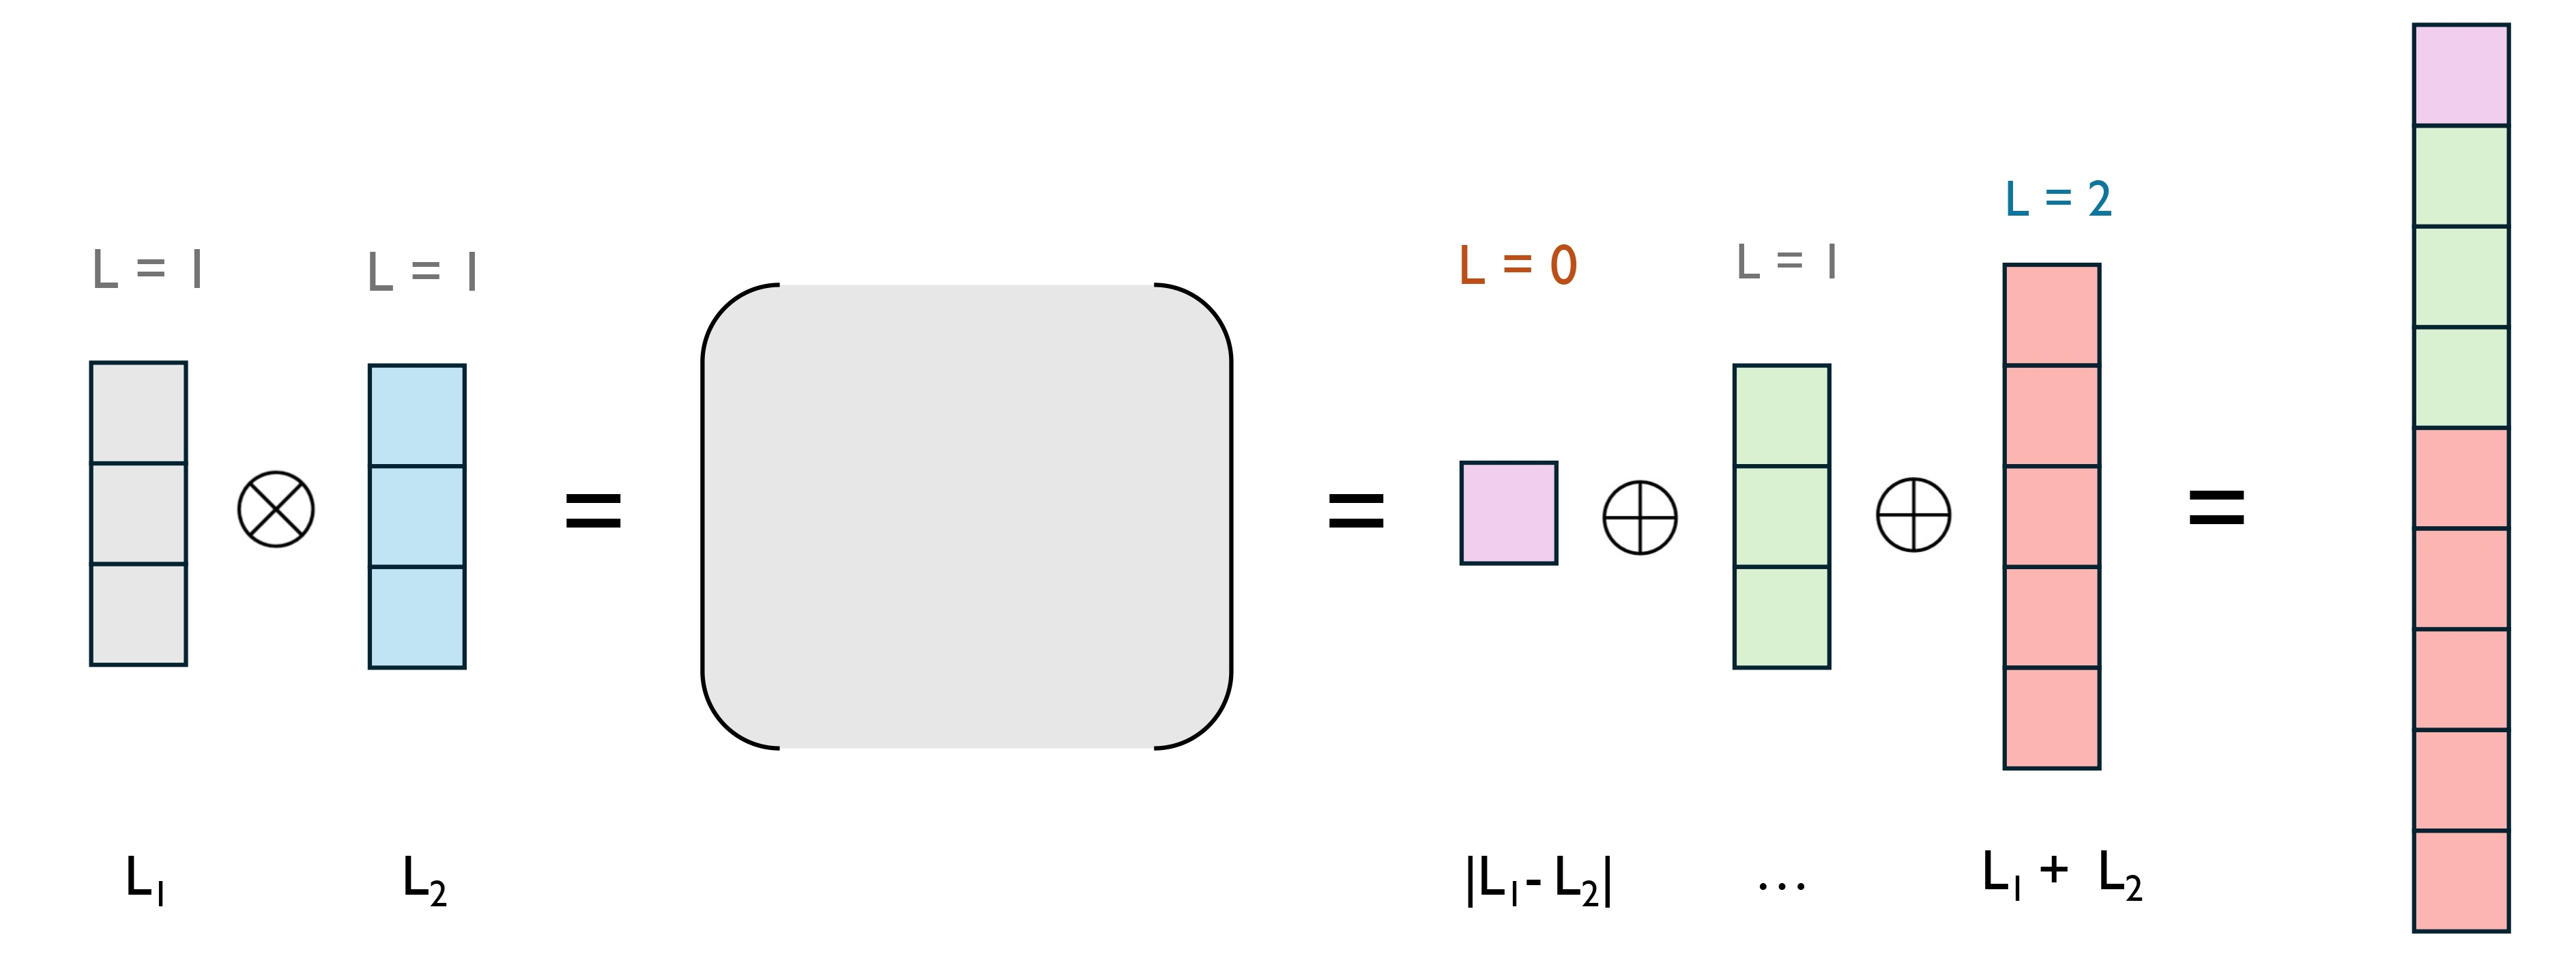

## Spherical Harmonics and tensors of different order



Let's start with a very high level introduction of spherical harmonics. It is a map from a point on the unit sphere to a real number (atleast in our context)

$$ Y_{m}^{l} : \mathbb{S}^2 → \mathbb{R}$$

For each $l$, $m$ varies from $-l$ to $l$ hence comprise of $2l + 1$ components. Objects of different l, react differently to the rotation.

**Why Spherical Harmonics?**

They have some nice properties including equivariance, which we will explore below.

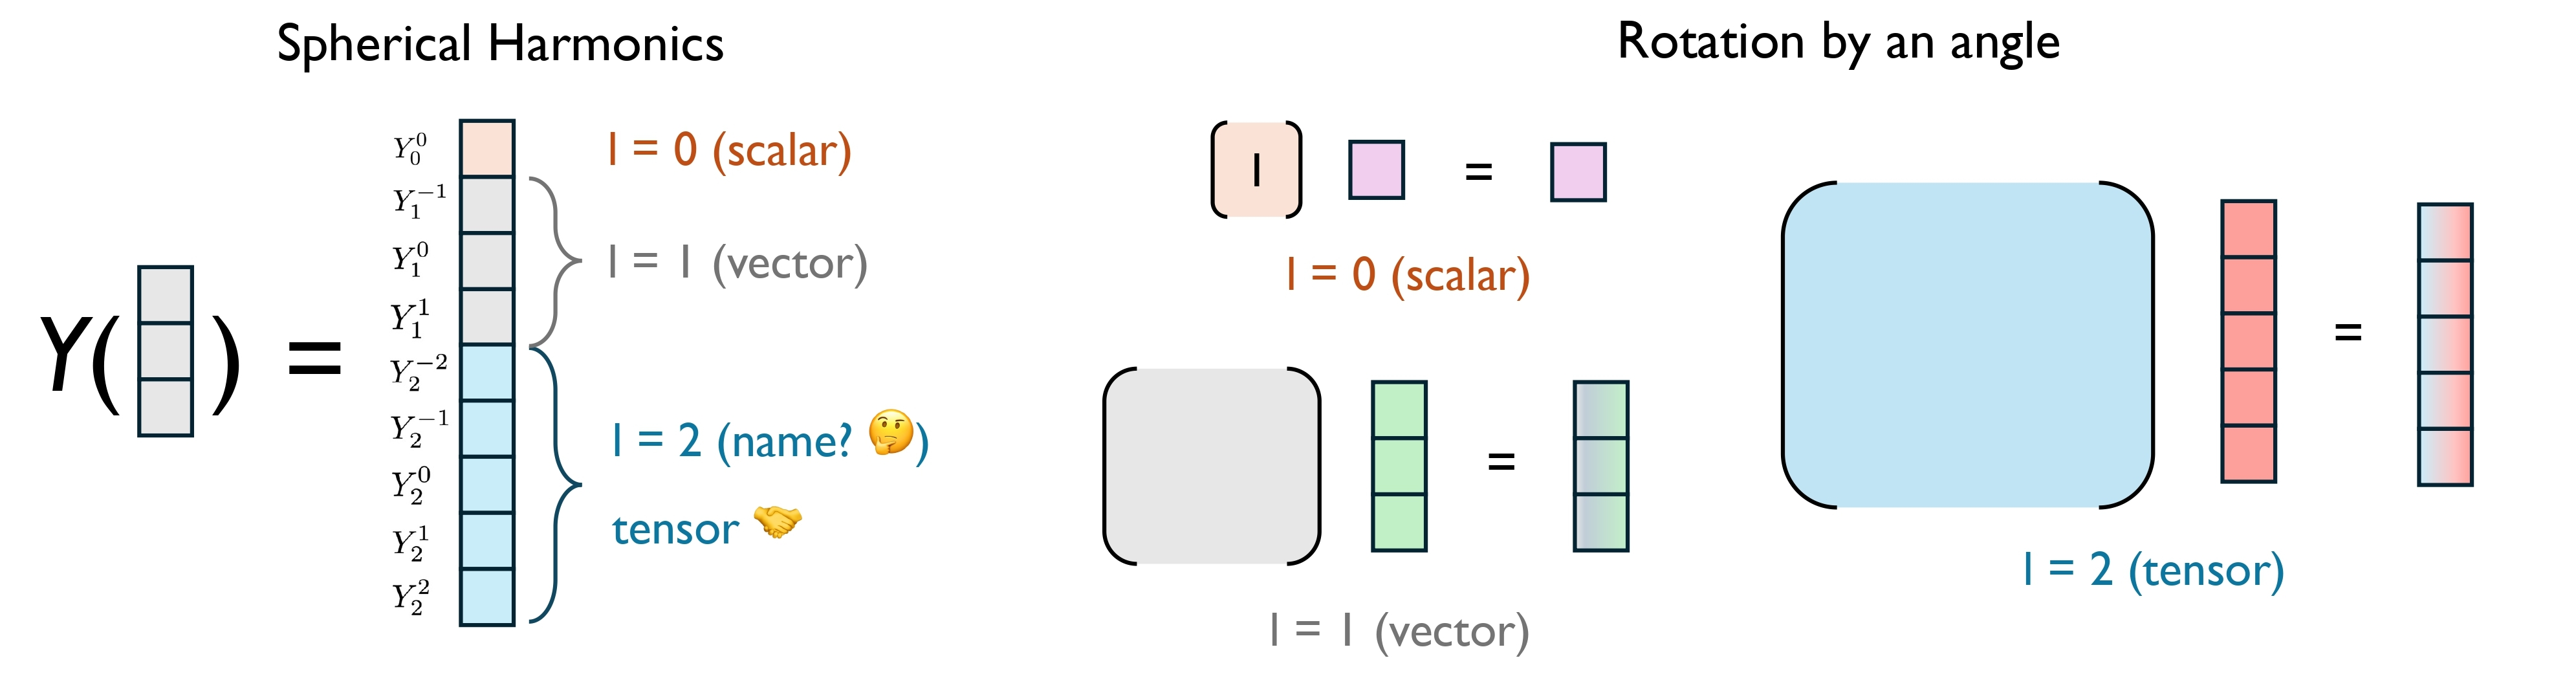

In [ ]:
#Don't worry about the next few lines, they are just work arounds to avoid some dependency issues.
import torch
import functools

_original_load = torch.load
torch.load = functools.partial(_original_load, weights_only=False)

from e3nn import o3 #e3nn is the package which NequIP/MACE use to handle operations involving geometric tensors
torch.load = _original_load

#Main portion which is to be focussed on
max_ell = 2
edge_vector = torch.tensor([1.0, 2.0, 3.0])

#Obtain a spherical harmonics representation of our edge vector
sph_har = o3.SphericalHarmonics([i for i in range(max_ell+1)], normalize=True)
sph_vector = sph_har(edge_vector)

print("Directional Component transformed through Spherical Harmonics is given by :")
print(sph_vector)
print(f"Shape : {sph_vector.shape}")

Directional Component transformed through Spherical Harmonics is given by :
tensor([ 0.2821,  0.1306,  0.2612,  0.3918,  0.2341,  0.1561, -0.0451,  0.4682,
         0.3122])
Shape : torch.Size([9])


Why is the array 9 elements long? We calculated the $l=0,1,2$ for all valid $m's$, and stored them in this format: $$[Y_0^0, \ \ Y_{1}^{-1}, Y_{1}^{0},Y_{1}^{1}, \ \ Y_{2}^{-2}, Y_{2}^{-1}, Y_{2}^{0}, Y_{2}^{1}, Y_{2}^{2}, ]$$

This array has 9 elements in total. Generally, this is how most arrays are stored in MACE. The final dimesion of the array combines the $l$ and $m$ indices, and concatenates the values like this.

The hyperparameter `max_ell` in MACE puts a cap on the maximum degree of spherical harmonics used in the expansion - hence controls the resolution in which directional component of the edge vector information is stored.

**Confused?** - Think of a fourier series expansion, the more number of higher frequency terms you introduce, the more sophisticated the representation is for your periodic function

### Equivariance with respect to rotation

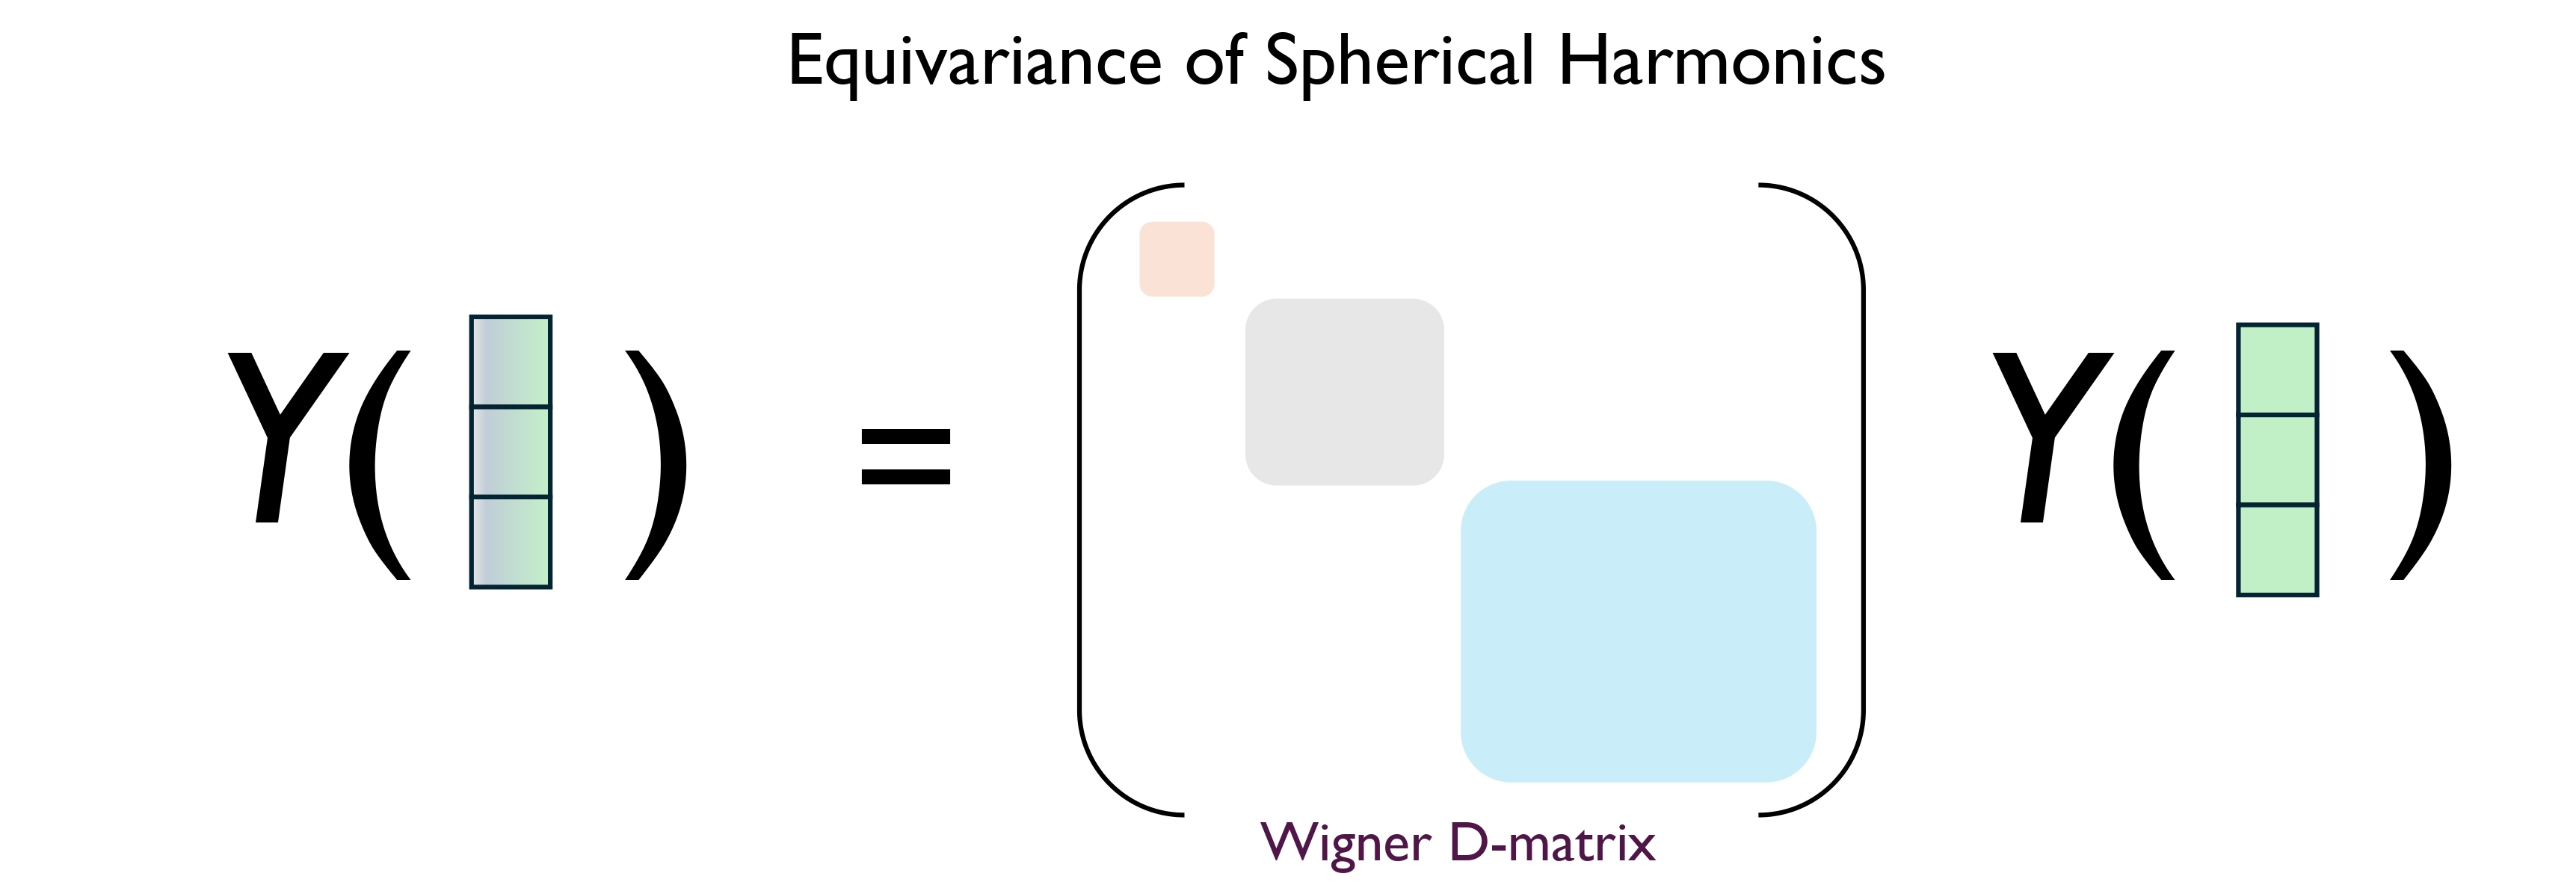

In [ ]:
angles = o3.rand_angles() #random angles for demonstration

#Spherical Harmonics of the rotated vector
irreps_in = o3.Irreps("1o") #our edge_vector is a l=1 object
rot_vector = torch.einsum("ij,j->i", irreps_in.D_from_angles(*angles), edge_vector)
sph_rot = sph_har(rot_vector)

#Spherical Harmonics of the original vector and the rotation
irreps_out = o3.Irreps("0e+1o+2e") #This says that the object is a direct sum of l=0, 1 and 2 components
rot_sph = torch.einsum("ij,j->i", irreps_out.D_from_angles(*angles), sph_vector)

In [ ]:
sph_rot

tensor([ 0.2821,  0.3194,  0.2576, -0.2653, -0.3877,  0.3765, -0.0523, -0.3128,
        -0.0724])

In [ ]:
rot_sph

tensor([ 0.2821,  0.3194,  0.2576, -0.2653, -0.3877,  0.3765, -0.0523, -0.3128,
        -0.0724])

## Additional : Why do we need tensor products?

In [ ]:
#Don't worry about the next few lines, they are just work arounds to avoid some dependency issues.
import torch
import functools

_original_load = torch.load
torch.load = functools.partial(_original_load, weights_only=False)

from e3nn import o3 #e3nn is the package which MACE uses to handle operations involving geometric tensors
torch.load = _original_load

# 1. Define the input irreps (concatenations of l's)
# irreps1 defines the geometric object type of l=1,
# irreps2 defines the geometric object type as a direct sum of l=0 and l=1 objects
irreps1 = o3.Irreps("1x1o")         # o/e symbolises odd/even - response to inversion
irreps2 = o3.Irreps("1x0e + 1x1o")

# 2. Instantiate the FullTensorProduct
# This module automatically calculates all possible |l1 - l2| to l1 + l2 combinations
tp = o3.FullTensorProduct(irreps1, irreps2)

# Print the resulting output irreps to see the combinations
print(f"Input 1: {irreps1}")
print(f"Input 2: {irreps2}")
print(f"Output:  {tp.irreps_out}")

# 3. Apply it to actual geometric tensors
max_ell = 1
edge_vector = torch.tensor([1.0, 2.0, 3.0])
sph_har = o3.SphericalHarmonics([i for i in range(max_ell+1)], normalize=True) #Defines Spherical Harmonics till l=1 type, as max_ell is defined as 1
sph_vector = sph_har(edge_vector)

tensor1 = torch.tensor([2.0, 4.0, 3.0])
tensor2 = sph_vector

# Compute the tensor product
output_tensor = tp(tensor1, tensor2)

print(f"\nShape of tensor 1: {tensor1.shape}")
print(f"Shape of tensor 2: {tensor2.shape}")
print(f"Shape of output:   {output_tensor.shape}")

Input 1: 1x1o
Input 2: 1x0e+1x1o
Output:  1x0e+1x1o+1x1e+1x2e

Shape of tensor 1: torch.Size([3])
Shape of tensor 2: torch.Size([4])
Shape of output:   torch.Size([12])


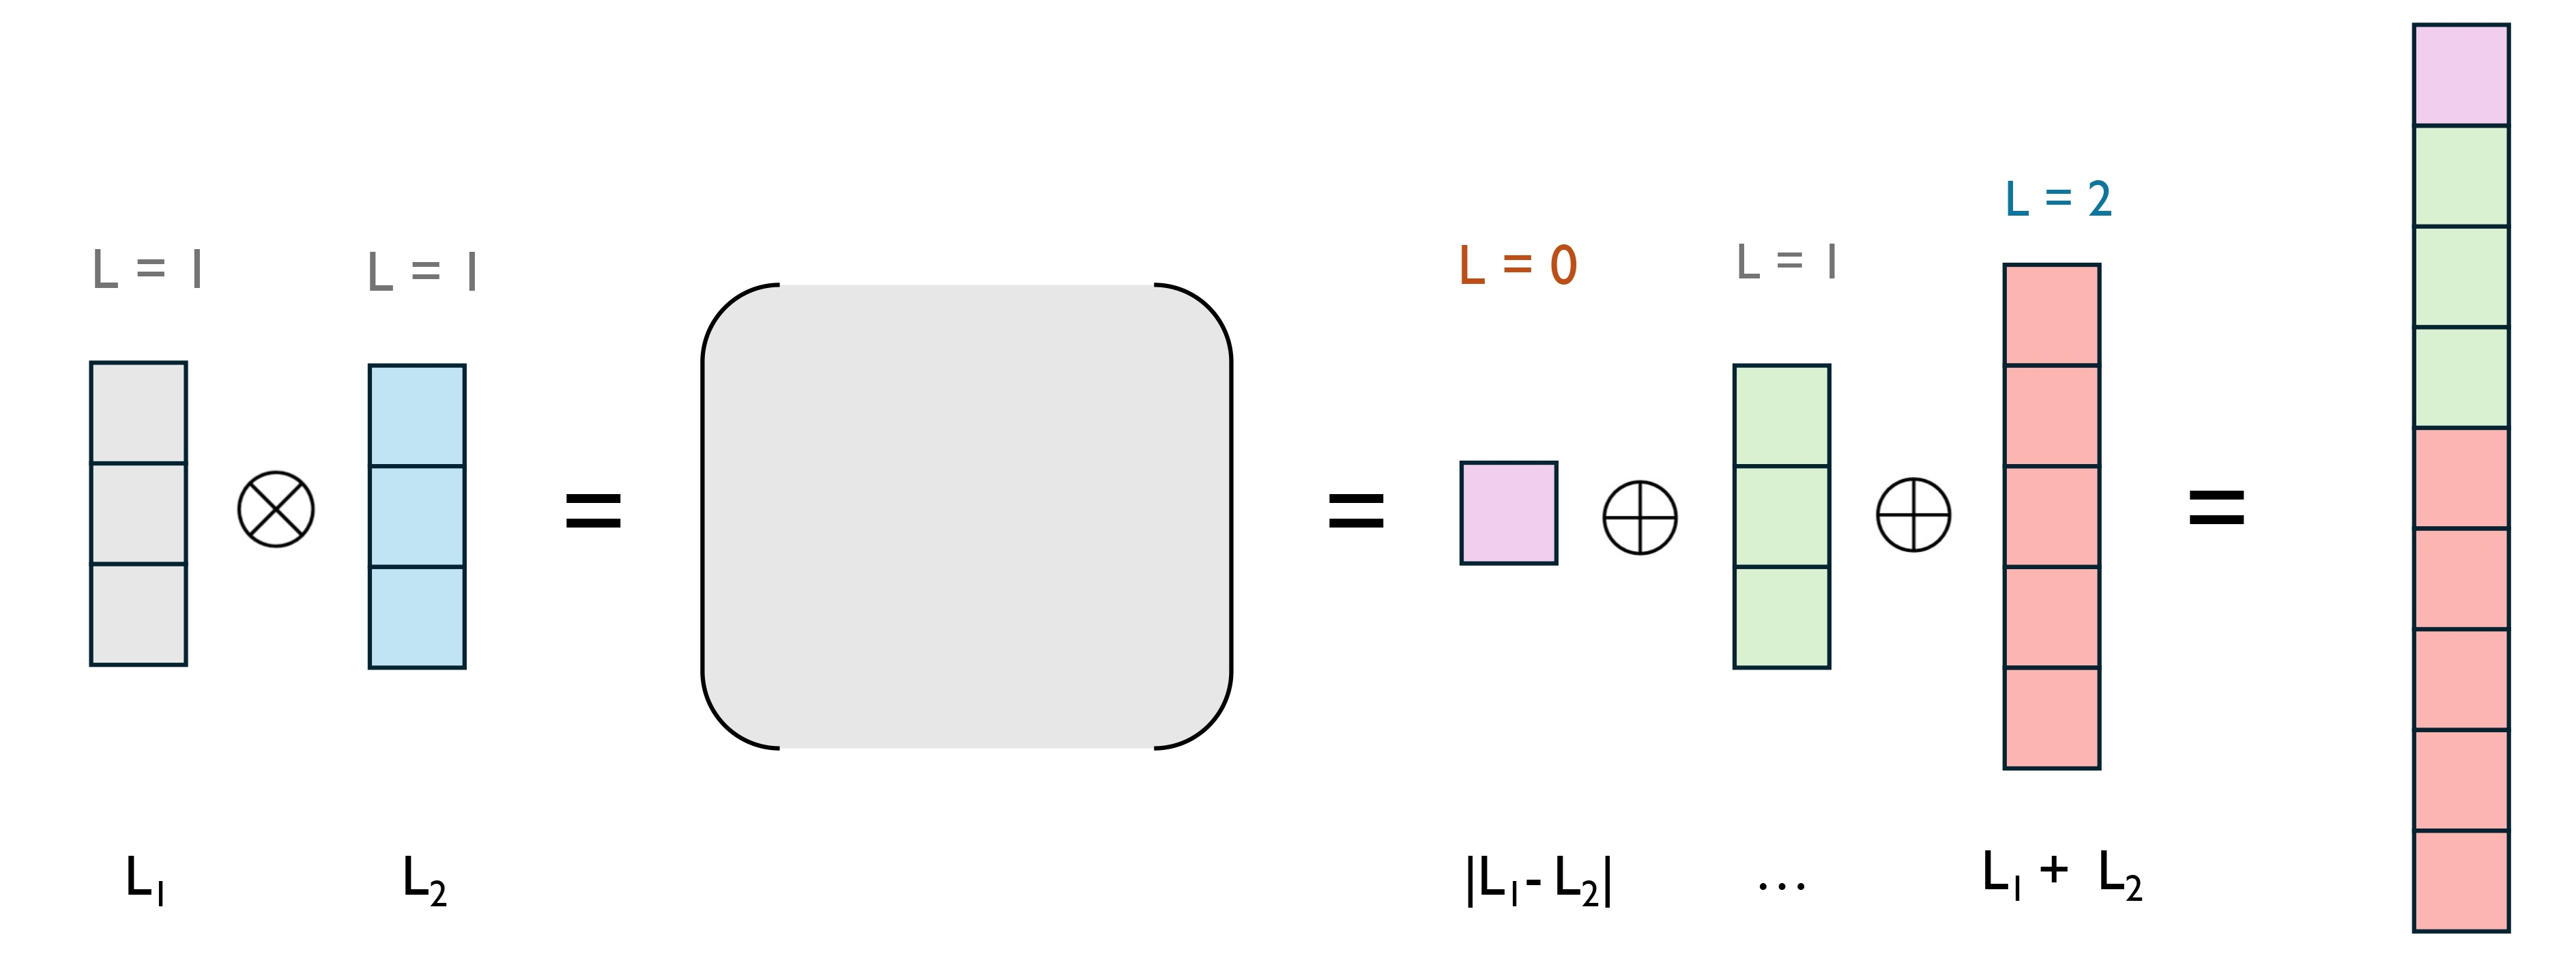

Notice the shape of these outputs!

When an object of type l=1 and l=0 undergoes tensor product, we get just an l=1 object (3 components)

When an object of type l=1 and l=1 undergoes tensor product, we get just an l=0 object (1 components), l=1 object (3 component), l=2 object (5 components)

so in total, 3 + 1 + 3 + 5 = 12 components.

While these rules just indicate the type of the output that we get, actual components (for eg : of l=1 object when two l=1 objects combines) using Clebsch-Gordon coefficients.

In [ ]:
#Define the type of object to which we are interesting in computing the tensor product
irreps1 = o3.Irreps("1x1o")
irreps2 = o3.Irreps("1x0e + 1x1o")

#Instantiate the FullTensorProduct
tp = o3.FullTensorProduct(irreps1, irreps2)
irreps_out = tp.irreps_out

print(f"Tensor 1 Irreps: {irreps1}")
print(f"Tensor 2 Irreps: {irreps2}")
print(f"Output Irreps:   {irreps_out}\n")

#Create random geometric tensors (1D tensors for a single example)
tensor1 = irreps1.randn(-1)
tensor2 = irreps2.randn(-1)

#Generate a random rotation (alpha, beta, gamma)
alpha, beta, gamma = o3.rand_angles()

#Extract the Wigner D-matrices for this specific rotation
#These matrices define how each object type transforms under the rotation
D1 = irreps1.D_from_angles(alpha, beta, gamma)
D2 = irreps2.D_from_angles(alpha, beta, gamma)
D_out = irreps_out.D_from_angles(alpha, beta, gamma)

# ==========================================
# PATH 1: Tensor Product -> Rotate
# ==========================================
#Compute the tensor product first
output_initial = tp(tensor1, tensor2)
#Rotate the result using the output's Wigner D-matrix
output_path1 = output_initial @ D_out.T

# ==========================================
# PATH 2: Rotate -> Tensor Product
# ==========================================
#Rotate the inputs using their respective Wigner D-matrices first
tensor1_rotated = tensor1 @ D1.T
tensor2_rotated = tensor2 @ D2.T
#Compute the tensor product of the rotated inputs
output_path2 = tp(tensor1_rotated, tensor2_rotated)

# ==========================================
# VERIFICATION
# ==========================================
#Compare the outputs (allowing for standard floating-point precision errors)
equivariance_holds = torch.allclose(output_path1, output_path2, atol=1e-5)

print("--- Equivariance Check ---")
print(f"Path 1 matches Path 2: {equivariance_holds}\n")

print("Path 1 (Rotate Output):")
print(output_path1)
print("\nPath 2 (Rotate Inputs):")
print(output_path2)

Tensor 1 Irreps: 1x1o
Tensor 2 Irreps: 1x0e+1x1o
Output Irreps:   1x0e+1x1o+1x1e+1x2e

--- Equivariance Check ---
Path 1 matches Path 2: True

Path 1 (Rotate Output):
tensor([ 1.3198,  0.6898, -2.3764,  0.3667,  0.0238, -0.1138, -0.7821,  0.0218,
        -0.1857,  1.9541, -0.4907,  0.1226])

Path 2 (Rotate Inputs):
tensor([ 1.3198,  0.6898, -2.3764,  0.3667,  0.0238, -0.1138, -0.7821,  0.0218,
        -0.1857,  1.9541, -0.4907,  0.1226])


# Dataset

As any MLIP architecture finds the mapping between the types and spatial coordinates of atoms to the potential energy, the quality, diversity, and relevance of the dataset significantly impact the performance and generalizability of the trained MLIP out of that. The dataset provides various atomic configurations and corresponding properties (e.g., energy, forces, stress) that the MLIP aims to predict. In this tutorial, we will consider a dataset of AIMD calculations on Silicon (at 800K).

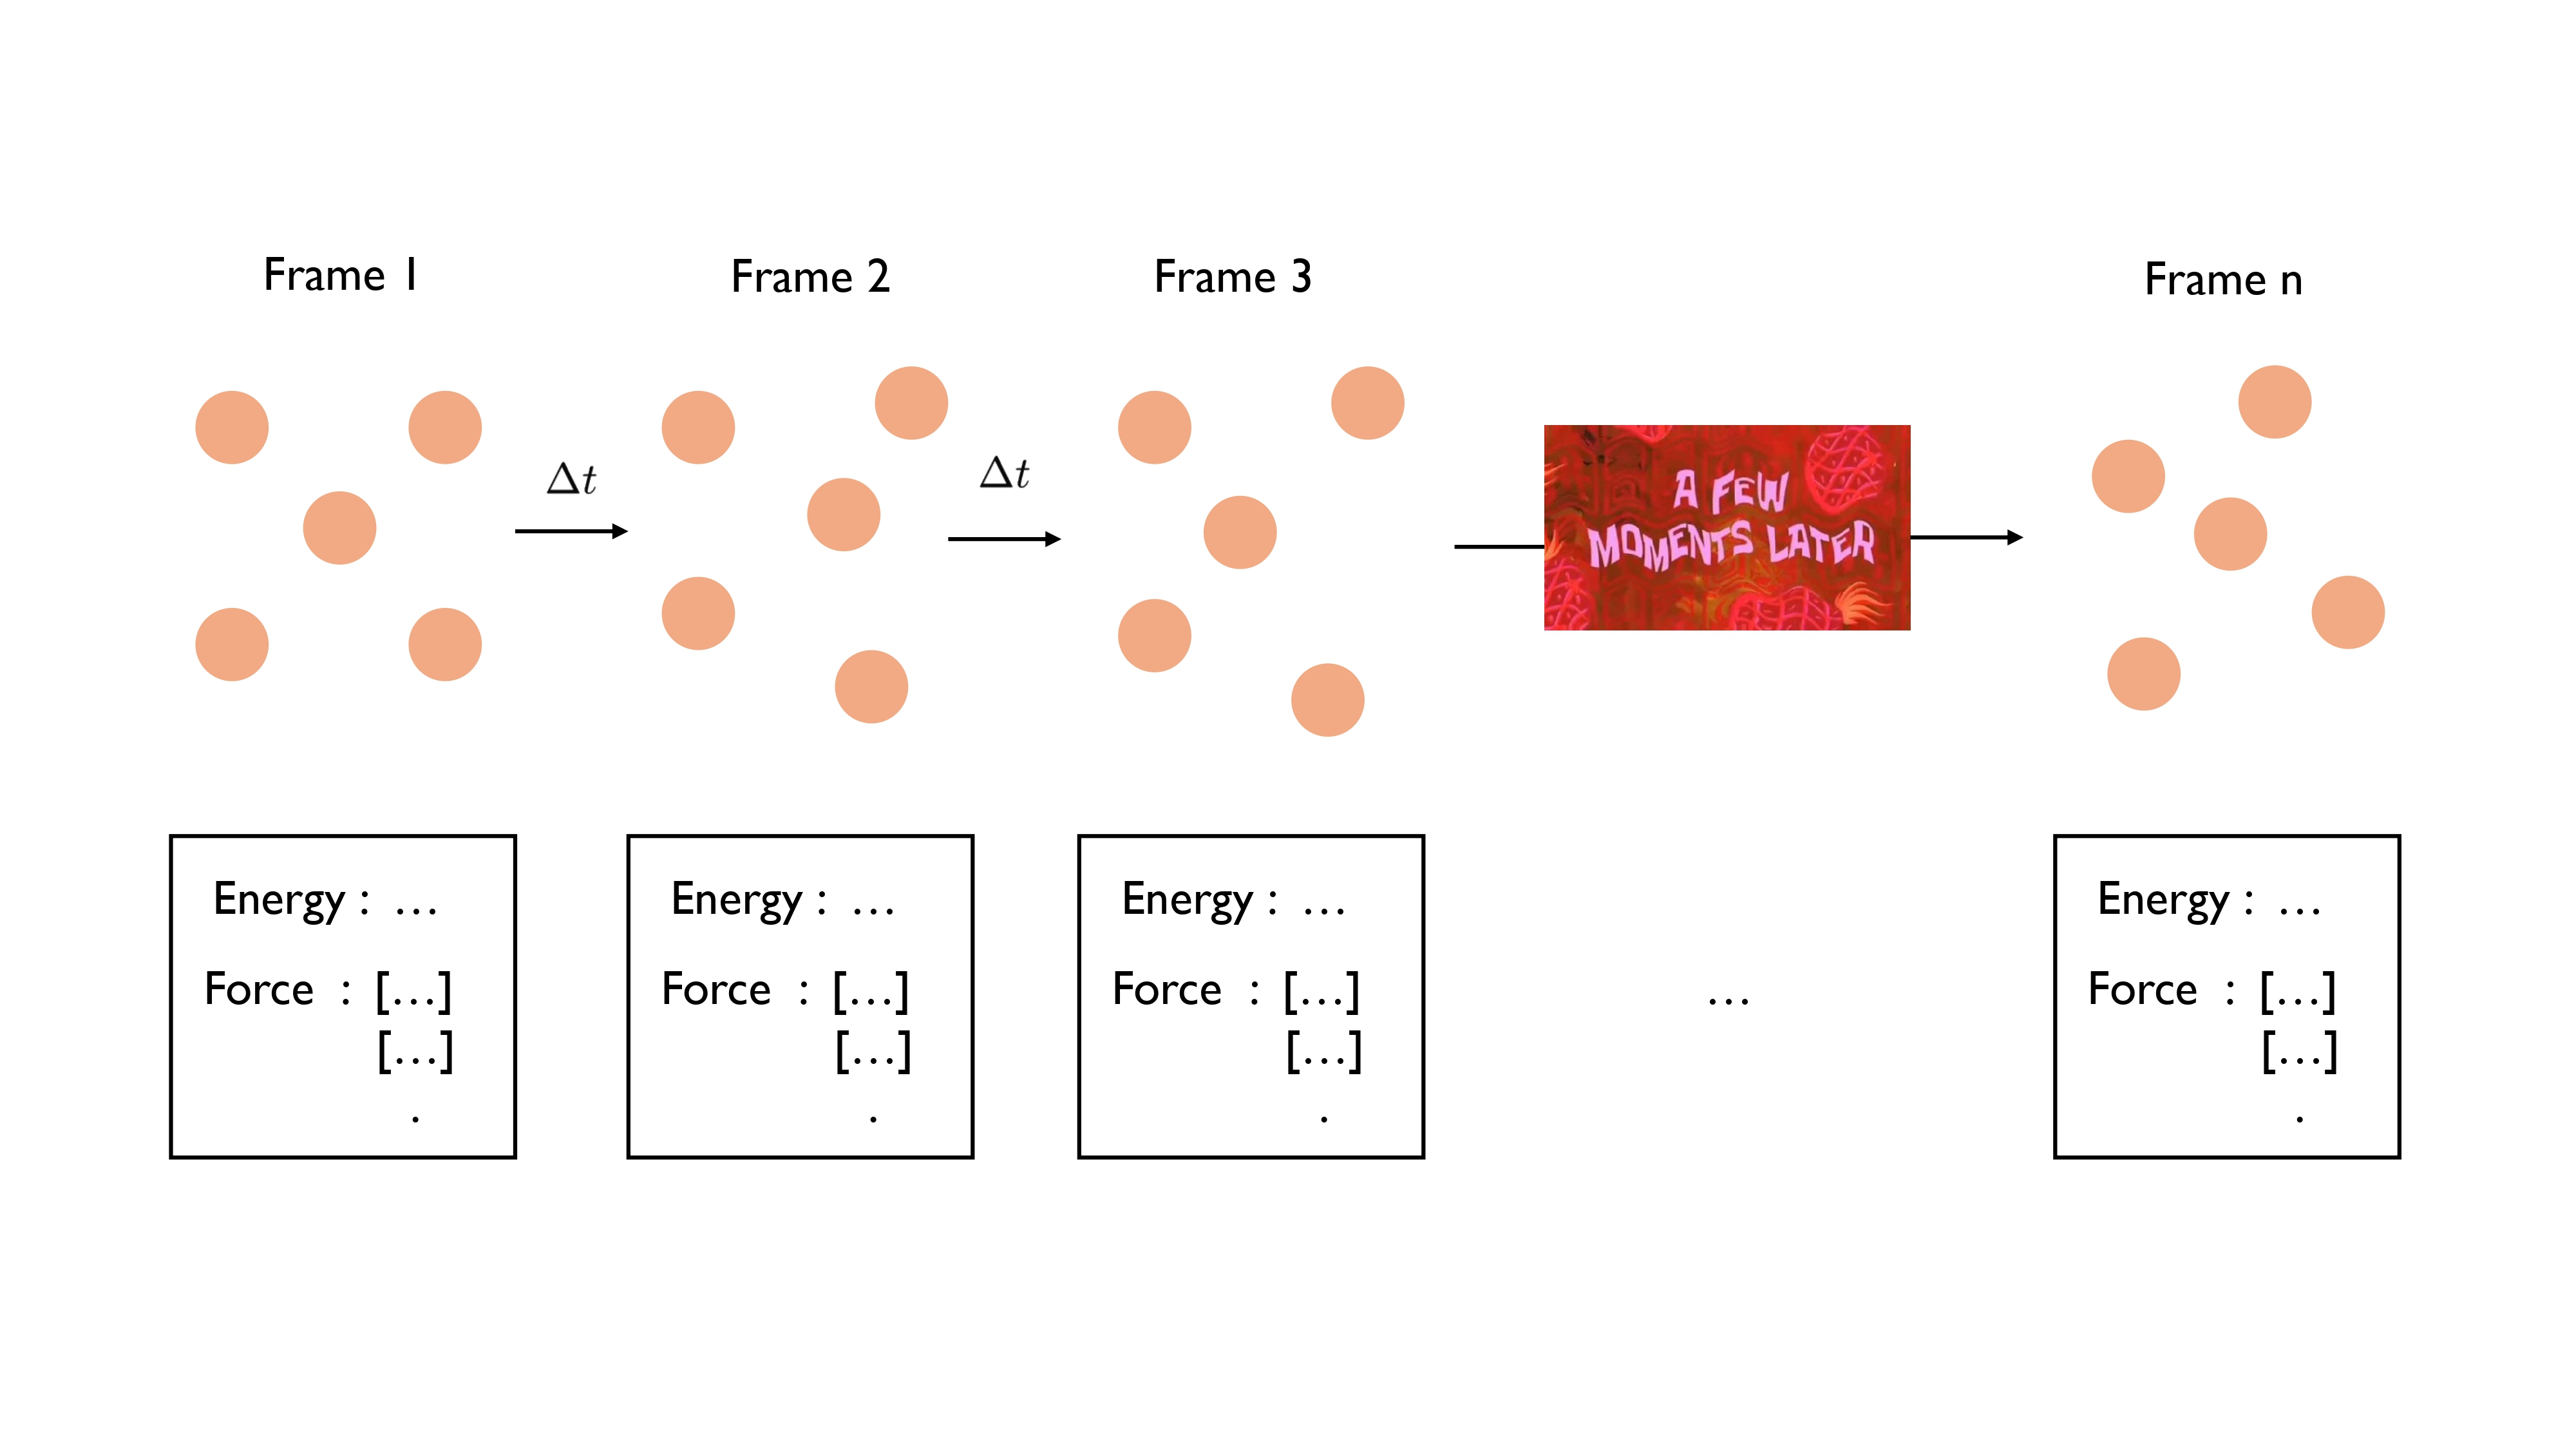

In [ ]:
%%capture
# download dataset and necessary files
!gdown --folder --id --no-cookies https://drive.google.com/drive/folders/1iFRzjr4tTYLIuC9w4bCW8swRH0HL6Z7M?usp=drive_link

In [ ]:
#Moving a necessary file to our working directory
!mv Si_data/mlip_utils.py ./

## Load and Visualize the dataset

In [ ]:
import os
from pathlib import Path

# Defining path to dataset for ease
dataset_dir = Path(os.getcwd())/'Si_data'
dataset_dir

PosixPath('/content/Si_data')

In [ ]:
#Let's load and understand the dataset
from ase.io import read, write

# Load the dataset
dataset = read("Si_data/Si_aimd.xyz", index=":")
dataset[0]

Atoms(symbols='Si64', pbc=True, cell=[10.861999859992501, 10.861999859992501, 10.861999859992501], calculator=SinglePointCalculator(...))

In [ ]:
num_configs = len(dataset)
print(f"Number of configurations in the dataset: {num_configs}")

Number of configurations in the dataset: 110


Let's utilise `ase.visualize` module to visualize one of the structures in the datset.

In [ ]:
from ase.visualize import view
view(dataset[10], viewer='x3d')

## Split into Train and Test parts

In [ ]:
from sklearn.model_selection import train_test_split

# Split into train (100) and test (10) (90-10 split)
train_set, test_set = train_test_split(dataset, test_size = 0.1, random_state = 123)

# Specify the train and test file path for ease
train_data_path = dataset_dir / "Si_train.xyz"
test_data_path = dataset_dir / "Si_test.xyz"

# Write them out to separate .xyz files
write(train_data_path, train_set)
write(test_data_path, test_set)

# NequIP

Welcome to the *NequIP Tutorial with Molecular Dynamics*, where we’ll train a NequIP model with AIMD data and use it for MD simulations!

NequIP employs E(3)-equivariant graph neural networks, which respect the symmetries of three-dimensional Euclidean space (rotations, translations, and reflections). This allows the model to learn both scalar (e.g., energy) and vector (e.g., forces) properties in a symmetry-aware manner.

So buckle up, and let’s dive into the NequIPverse.

Find the link to the [documentation](https://nequip.readthedocs.io/en/latest/index.html) and the [original paper](https://doi.org/10.1038/s41467-022-29939-5) of NequIP here.



In [ ]:
# Import necessary libraries (If any of the libraries doesn't install, you can use pip install the package)
import random
import time
import json
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import pylab as pl
import torch
import ase

In [ ]:
# Determine device is CPU or GPU
device ='cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
#Specify Paths
nequip_dir = Path(os.getcwd()) / 'NequIP'
nequip_configs_dir = nequip_dir / 'configs'
nequip_results_dir = nequip_dir / 'results'

# Create directories if not exists
os.makedirs(nequip_dir, exist_ok=True)
os.makedirs(nequip_configs_dir, exist_ok=True)
os.makedirs(nequip_results_dir, exist_ok=True)

For configuring the hyperparameters, we can specify a YAML file. The following is an example:

<details>
<summary>Click to see the list of the hyperparameters worth knowing:</summary>
    
<br>

- **`r_max`: Cutoff Radius**

The cutoff used to create the local environment in each layer. `r_max=5.0` means atoms separated by a distance of more than 5.0 Å do not directly communicate in a single layer.

- **`l_max` : Maximum Irrep. Order**

The maximum irrep order (rotation order) for the network's features, l=1 is a good default, l=2 is more accurate but slower.

- **`num_features` : Multiplicity of the features**

32 is suggested as a good default value.

- **`num_bessels` : Number of Bessel Functions**

Number of basis functions used in the radial Bessel basis, the default of 8 usually works well

In [ ]:
# For a more detailed/involved explanation of the components of the yaml file, visit : https://github.com/mir-group/nequip/blob/main/configs/tutorial.yaml
import yaml

parameters_nequip = {
    # ===========
    #    RUN
    # ===========
    "run": ["train"],      # If you want the test metrics too, use ["train", "test"]
    "cutoff_radius": 4.0,  # r_max is defined through this variable
    "num_layers": 4,       # number of interaction blocks, authors recommend 3-5 to work best
    "l_max": 1,            # the maximum irrep order (rotation order) for the network's features, l=1 is a good default, l=2 is more accurate but slower
    "num_features": 64,

    # The model operates on atom type indices rather than chemical species, so we need to specify `model_type_names`.
    # In the common case, type names correspond directly to chemical symbols (e.g. [C, H, O, Cu]) and the mapping is an identity.
    # Custom type names (e.g. "my_Cu") are possible but require an explicit `chemical_species_to_atom_type_map`.
    # `model_type_names` show up as arguments across different categories (data, model, metrics, callbacks), so we define
    # a single source of truth here and use variable interpolation to keep them consistent.
    "model_type_names": ["Si"],
    "chemical_species": "${model_type_names}",
    "monitored_metric": "val0_epoch/weighted_sum",

    # We want a metric to condition training on (e.g. for best `ModelCheckpoint`, `EarlyStopping`, LR scheduling) which will show up in various places later on, so we set up a "single source of truth" to interpolate over
    # see https://nequip.readthedocs.io/en/latest/guide/configuration/metrics.html

    # ============
    #    DATA
    # ============

    # For more info : https://nequip.readthedocs.io/en/latest/guide/configuration/data.html
    "data": {
        "_target_": "nequip.data.datamodule.ASEDataModule",
        "seed": 123,

        # here we take an ASE-readable file (in xyz/extxyz format) and split it into train:val = 90:10
        "split_dataset": {
            "file_path": str(train_data_path),
            "train": 0.9,
            "val": 0.1 #add a "test" : <fraction> tag here incase you wish to test
        },

        # `transforms` convert data from the Dataset to a form that can be used by the ML model
        "transforms": [
            {
                "_target_": "nequip.data.transforms.ChemicalSpeciesToAtomTypeMapper",
                "model_type_names": "${model_type_names}"
            },
            {
                "_target_": "nequip.data.transforms.NeighborListTransform",
                "r_max": "${cutoff_radius}"
            }
        ],
        "train_dataloader": {
            "_target_": "torch.utils.data.DataLoader",
            "batch_size": 10,
            "num_workers": 2,
            "shuffle": True
        },
        "val_dataloader": {
            "_target_": "torch.utils.data.DataLoader",
            "batch_size": 10,
            "num_workers": "${data.train_dataloader.num_workers}"
        },
        "test_dataloader": "${data.val_dataloader}",
        "stats_manager": {
            "_target_": "nequip.data.CommonDataStatisticsManager",
            "dataloader_kwargs": {
                "batch_size": 10
            },
            "type_names": "${model_type_names}"
        }
    },

    # =============
    #   TRAINER
    # =============
    "trainer": {
        "_target_": "lightning.Trainer",
        "accelerator": "gpu",
        "enable_checkpointing": True,
        "max_epochs": 30,
        "log_every_n_steps": 5,
        "logger": {
            "_target_": "lightning.pytorch.loggers.CSVLogger",
            "save_dir": str(nequip_results_dir),
            "name": "training_logs"
        },
        "callbacks": [
            {
                "_target_": "lightning.pytorch.callbacks.EarlyStopping",
                "monitor": "${monitored_metric}",
                "min_delta": 1e-3,
                "patience": 20
            },
            {
                "_target_": "lightning.pytorch.callbacks.ModelCheckpoint",
                "monitor": "${monitored_metric}",
                "dirpath": str(nequip_results_dir),
                "filename": "best",
                "save_last": True
            }
        ]
    },

    # =====================
    #   TRAINING MODULE
    # =====================
    "training_module": {
        "_target_": "nequip.train.EMALightningModule",
        "ema_decay": 0.999,

        "loss": {
            "_target_": "nequip.train.EnergyForceLoss",
            "per_atom_energy": True,
            "coeffs": {
                "total_energy": 1.0,
                "forces": 1.0
            }
        },

        "val_metrics": {
            "_target_": "nequip.train.EnergyForceMetrics",
            "coeffs": {
                "total_energy_mae": 1.0,
                "forces_mae": 1.0
                # keys `total_energy_rmse` and `forces_rmse`, `per_atom_energy_rmse` and `per_atom_energy_mae` are also available
                # we could have train_metrics and test_metrics be different from val_metrics, but it makes sense to have them be the same
            }
        },
        "train_metrics": "${training_module.val_metrics}",
        "test_metrics": "${training_module.val_metrics}",

        "optimizer": {
            "_target_": "torch.optim.Adam",
            "lr": 0.01
        },

        "lr_scheduler": {
            "scheduler": {
                "_target_": "torch.optim.lr_scheduler.ReduceLROnPlateau",
                "factor": 0.6,
                "patience": 5,
                "threshold": 0.2,
                "min_lr": 1e-6
            },
            "monitor": "${monitored_metric}",
            "interval": "epoch",
            "frequency": 1
        },

        "model": {
            "_target_": "nequip.model.NequIPGNNModel",

            # == basic model params ==
            "seed": 123,
            "model_dtype": "float32",
            "type_names": "${model_type_names}",
            "r_max": "${cutoff_radius}",

            # == bessel encoding ==
            "num_bessels": 8,          # number of basis functions used in the radial Bessel basis, the default of 8 usually works well
            "bessel_trainable": False, # set true to train the bessel weights (default false)
            "polynomial_cutoff_p": 6,  # p-exponent used in polynomial cutoff function, smaller p corresponds to stronger decay with distance

            # == convnet layers ==
            "num_layers": "${num_layers}",
            "l_max": "${l_max}",
            "parity": True,
            "num_features": "${num_features}",

            # == radial network ==
            "radial_mlp_depth": 2,    # number of radial layers, usually 1-3 works best, smaller is faster
            "radial_mlp_width": 64,   # number of hidden neurons in radial function, smaller is faster

            # see https://nequip.readthedocs.io/en/latest/guide/configuration/model.html to understand the following hyperparameters
            "avg_num_neighbors": "${training_data_stats:num_neighbors_mean}",
            "per_type_energy_scales": "${training_data_stats:per_type_forces_rms}",
            "per_type_energy_shifts": "${training_data_stats:per_atom_energy_mean}",
            "per_type_energy_scales_trainable": False,
            "per_type_energy_shifts_trainable": False,

            "pair_potential": {
                "_target_": "nequip.nn.pair_potential.ZBL",
                "units": "metal",
                "chemical_species": "${chemical_species}"
            }
        }
    }
}

input_nequip = nequip_configs_dir / "input.yaml"

with open(input_nequip, "w") as file:
    yaml.dump(parameters_nequip, file, default_flow_style=False, sort_keys=False)

print(f"Parameters have been saved to {input_nequip}")

Parameters have been saved to /content/NequIP/configs/input.yaml


In [ ]:
!nequip-train -cd './NequIP/configs' -cn input

[2026-09-23 13:10:43,777][nequip.scripts.train][INFO] - [rank: 0] Starting fresh training ...
[2026-09-23 13:10:43,780][nequip.utils.versions.package_versions][INFO] - [rank: 0] Version Information:
[2026-09-23 13:10:43,780][nequip.utils.versions.package_versions][INFO] - [rank: 0] torch 2.11.0+cu128
[2026-09-23 13:10:43,780][nequip.utils.versions.package_versions][INFO] - [rank: 0] e3nn 0.6.0
[2026-09-23 13:10:43,780][nequip.utils.versions.package_versions][INFO] - [rank: 0] nequip 0.19.1
[2026-09-23 13:10:43,780][nequip.scripts.train][INFO] - [rank: 0] This `nequip-train` run will perform the following tasks: ['train']
[2026-09-23 13:10:43,780][nequip.scripts.train][INFO] - [rank: 0] and use the output directory provided by Hydra: /content/outputs/2026-09-23/13-10-43
[2026-09-23 13:10:44,211][nequip.scripts.train][INFO] - [rank: 0] Building datamodule ...
[2026-09-23 13:10:44,229][nequip.data.datamodule._base_datamodule][INFO] - [rank: 0] Found 1 training dataset(s), 1 validation dat

In [ ]:
# Load the CSV file
df = pd.read_csv(nequip_results_dir / "training_logs/version_0/metrics.csv")

df.head()

,epoch,step,train_loss_epoch/forces_mse,train_loss_epoch/per_atom_energy_mse,train_loss_epoch/weighted_sum,train_loss_step/forces_mse,train_loss_step/per_atom_energy_mse,train_loss_step/weighted_sum,train_metric_epoch/forces_mae,train_metric_epoch/forces_maxabserr,...,val0_epoch/forces_mae,val0_epoch/forces_maxabserr,val0_epoch/forces_rmse,val0_epoch/per_atom_energy_mae,val0_epoch/per_atom_energy_maxabserr,val0_epoch/per_atom_energy_rmse,val0_epoch/total_energy_mae,val0_epoch/total_energy_maxabserr,val0_epoch/total_energy_rmse,val0_epoch/weighted_sum
0,0,4,NaN,NaN,NaN,0.196205,0.176528,0.186366,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.329797,1.81037,0.42226,0.051042,0.082877,0.052561,3.266697,5.304147,3.363872,1.798247
2,0,8,0.285645,0.412286,0.348965,NaN,NaN,NaN,0.400191,3.892842,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,9,NaN,NaN,NaN,0.151550,0.103405,0.127478,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,14,NaN,NaN,NaN,0.167876,0.029722,0.098799,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


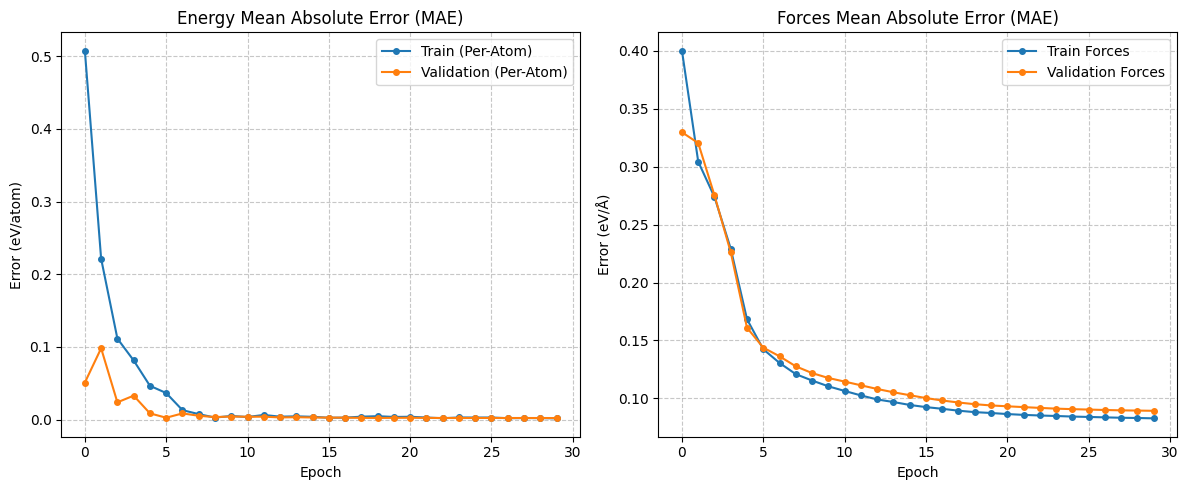

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Clean the data by aggregating by epoch
epoch_metrics = df.groupby('epoch').mean(numeric_only=True).reset_index()

# Create the plot
plt.figure(figsize=(12, 5))

# Subplot 1: Energy Error
plt.subplot(1, 2, 1)
plt.plot(epoch_metrics['epoch'], epoch_metrics['train_metric_epoch/per_atom_energy_mae'], label='Train (Per-Atom)', marker='o', markersize=4)
plt.plot(epoch_metrics['epoch'], epoch_metrics['val0_epoch/per_atom_energy_mae'], label='Validation (Per-Atom)', marker='o', markersize=4)
plt.title('Energy Mean Absolute Error (MAE)')
plt.xlabel('Epoch')
plt.ylabel('Error (eV/atom)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Subplot 2: Forces Error
plt.subplot(1, 2, 2)
plt.plot(epoch_metrics['epoch'], epoch_metrics['train_metric_epoch/forces_mae'], label='Train Forces', marker='o', markersize=4)
plt.plot(epoch_metrics['epoch'], epoch_metrics['val0_epoch/forces_mae'], label='Validation Forces', marker='o', markersize=4)
plt.title('Forces Mean Absolute Error (MAE)')
plt.xlabel('Epoch')
plt.ylabel('Error (eV/Å)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# MD with NequIP

In [ ]:
from mlip_utils import *

!nequip-compile \
  "./NequIP/results/best.ckpt" \
  "./NequIP/compiled_model.nequip.pt2" \
  --device cuda \
  --mode aotinductor \
  --target ase

[2026-09-23 13:15:45,449][nequip.scripts.compile][INFO] - [rank: 0] Compiling for device: cuda
[2026-09-23 13:15:45,450][nequip.model.saved_models.load_utils][INFO] - [rank: 0] Loading model from ./NequIP/results/best.ckpt ...
[2026-09-23 13:15:45,450][nequip.model.saved_models.checkpoint][INFO] - [rank: 0] Loading model from checkpoint file: NequIP/results/best.ckpt ...
[2026-09-23 13:15:46,711][nequip.train.ema][INFO] - [rank: 0] Loading EMA weights for evaluation model.
[2026-09-23 13:15:46,749][nequip.data.datamodule._base_datamodule][INFO] - [rank: 0] Found 1 training dataset(s), 1 validation dataset(s), 0 test dataset(s), and 0 predict dataset(s).
/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
W0923 13:17:11.605000 11248 torch/_inductor/utils.py:1731] Not enough SMs to use max_autotune_gemm mode
W0923 13:17:20.039000 11248 torch/

In [ ]:
from nequip.integrations.ase import NequIPCalculator

calculator = NequIPCalculator.from_compiled_model(
    compile_path="./NequIP/compiled_model.nequip.pt2",
    device="cuda",  # or "cpu"
)

/usr/local/lib/python3.13/dist-packages/nequip/integrations/utils.py:14: UserWarning: Defaulting to using model type names as chemical symbols. If the model type names correspond exactly to chemical species (e.g., 'H', 'C', 'O'), this is correct. Otherwise, this is wrong and will cause errors. To silence this warning, explicitly set `chemical_species_to_atom_type_map=True` for identity mapping, or provide the correct mapping as a dict.
  warnings.warn(


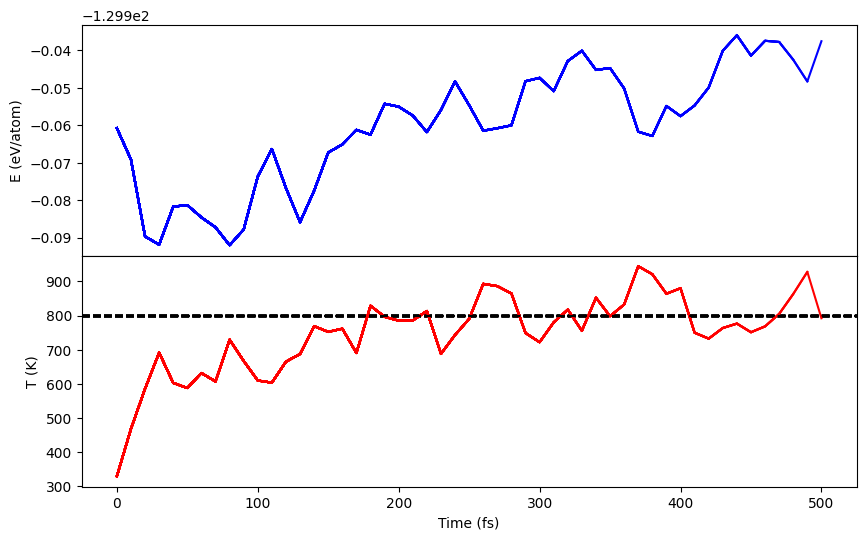

MD finished in 0.24 minutes!


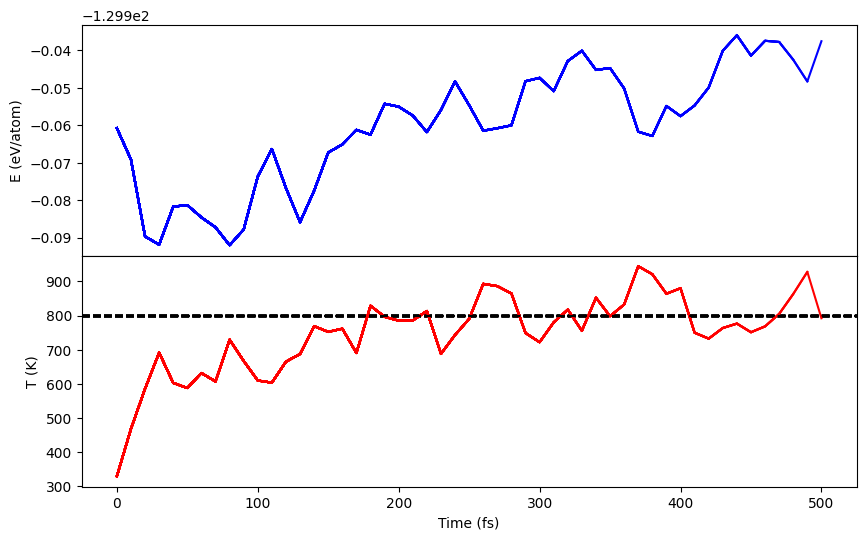

In [ ]:
init_conf = read(test_data_path, index=0)
simpleMD(init_conf, temp=800, calc=calculator, fname= './nequip_md_si_800K.xyz', s=10, T=500)

# How can I trust my MLIP (not an exhaustive list)?



*   Through the metrics that can be seen for validation and test sets (with respect to force and errors).
*   Whether the MD run is stable?
*   Whether the physics that I get out of MD makes sense?



# Visualizing `.xyz` files

We can visualize the Molecular Dynamics file using softwares such as [OVITO](https://www.ovito.org/).

1. This can be done by downloading and installing OVITO software on your local device from the following website - [Download OVITO](https://www.ovito.org/#download)

2. After downloading it, open the application. [Refer this for usage instructions](https://www.ovito.org/manual).

3. Go to `Files`->`Load File...`-> Load the Trajectory File.

4. Play the animation.

In [ ]:
from google.colab import files

files.download('nequip_md_si_800K.xyz')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>